In [1]:
import sys, os
_base = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(_base, 'kepler-mapper'))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import kmapper as km
import kmapper.evaluate as evaluate
from sklearn import cluster


In [3]:
def load_obj(obj_path):
    points = []
    with open(obj_path) as f:
        for line in f:
            parts = line.split()
            if parts and parts[0] == "v":
                points.append([float(x) for x in parts[1:4]])
    return np.array(points)

data = load_obj('cat-reference.obj')
mapper = km.KeplerMapper(verbose=0)
projected_data = mapper.fit_transform(data)
clusterer = cluster.DBSCAN(eps=0.1, min_samples=5)


In [4]:
import numpy as np
import time

N_SAMPLES = 50
SEED = 42
N_LB, N_UB = 7, 25
OUTPUT_FILE = 'results_output_cat_random.txt'

rng = np.random.default_rng(SEED)
n_candidates = rng.integers(N_LB, N_UB + 1, size=N_SAMPLES)
p_candidates = rng.uniform(0.1, 0.7, size=N_SAMPLES)

best_tsc = -np.inf
best_n, best_p, best_iter = None, None, 0

start_time = time.time()
for i, (n_val, p_val) in enumerate(zip(n_candidates, p_candidates)):
    n = int(n_val)
    p = float(p_val)
    try:
        cover = km.Cover(n_cubes=n, perc_overlap=p)
        graph = mapper.map(projected_data, data, clusterer=clusterer, cover=cover)
        tsc = evaluate.compute_SC_adj(data, projected_data, graph, cover, type='k', cluster=clusterer)
    except Exception:
        tsc = 0.0
    if tsc > best_tsc:
        best_tsc = tsc
        best_n, best_p, best_iter = n, p, i
total_time = time.time() - start_time
convergence_time = total_time * (best_iter + 1) / N_SAMPLES

with open(OUTPUT_FILE, 'a') as f:
    f.write("=== Random-Mapper ===\n")
    f.write(f"Best n: {best_n}\n")
    f.write(f"Best a: {round(best_p, 3)}\n")
    f.write(f"Best TSC: {round(best_tsc, 4)}\n")
    f.write(f"Convergence iteration: {best_iter}\n")
    f.write(f"Convergence time: {convergence_time:.4f}s\n")
    f.write(f"Total time: {total_time:.4f}s\n\n")

print(f"Best N={best_n}, p={round(best_p, 3)}, TSC={round(best_tsc, 4)}")
print(f"Found at iteration {best_iter}, convergence_time={convergence_time:.4f}s, total={total_time:.4f}s")


100%|██████████| 100/100 [00:05<00:00, 16.94it/s]


SC:0.0465398027
SC_norm:0.52326990135
TSR:1.0
SC_adj:0.761634950675


100%|██████████| 100/100 [00:04<00:00, 21.23it/s]


SC:-0.07345192363919897
SC_norm:0.4632740381804005
TSR:1.0
SC_adj:0.7316370190902003


100%|██████████| 100/100 [00:02<00:00, 33.59it/s]


...

SC:-0.15132570814920776
SC_norm:0.4243371459253961
TSR:1.0
SC_adj:0.7121685729626981


100%|██████████| 100/100 [00:03<00:00, 27.62it/s]


SC:-0.03869809160367836
SC_norm:0.48065095419816084
TSR:1.0
SC_adj:0.7403254770990804


100%|██████████| 100/100 [00:03<00:00, 33.00it/s]


SC:-0.0030129682475523805
SC_norm:0.4984935158762238
TSR:0.6666666666666666
SC_adj:0.5825800912714452
Best N=10, p=0.273, TSC=0.7637
Found at iteration 22, convergence_time=201.9055s, total=438.9250s


# Random-Mapper — Final Graph

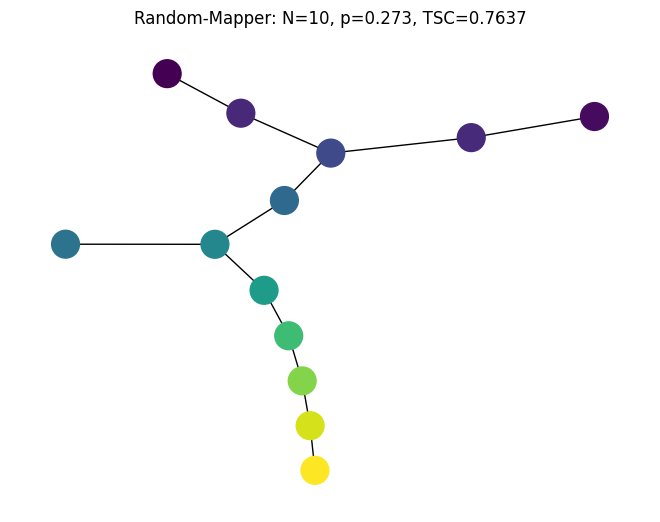

100%|██████████| 100/100 [00:05<00:00, 17.28it/s]


SC:0.0546168310936
SC_norm:0.5273084155468
TSR:1.0
SC_adj:0.7636542077734


0.7636542077734

In [5]:
cover = km.Cover(n_cubes=best_n, perc_overlap=best_p)
graph = mapper.map(projected_data, data, clusterer=clusterer, cover=cover)

color_list = [np.mean(projected_data[list(v)]) for v in graph['nodes'].values()]
G = km.adapter.to_networkx(graph)
nx.draw(G, pos=nx.kamada_kawai_layout(G), node_color=color_list, node_size=400, cmap='viridis')
plt.title(f"Random-Mapper: N={best_n}, p={round(best_p,3)}, TSC={round(best_tsc,4)}")
plt.savefig('random_mapper_cat.png', bbox_inches='tight')
plt.show()

evaluate.compute_SC_adj(data, projected_data, graph, cover, type='k', cluster=clusterer)
